## Purpose
This notebook will identify last 3 months best perfomer

In [75]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, current_date, date_sub
import configparser
import os
import pandas as pd
import matplotlib.pyplot as plt
import datetime

In [76]:
config = configparser.ConfigParser()
config.read(os.path.join(os.path.dirname(os.path.abspath("__file__")), '../conf/config.ini'))
url = 'jdbc:mysql://localhost/{}'.format(config.get('mysql', 'database'))
driver = config.get('mysql', 'driver')
tablename = "stocksinfp"
username = config.get('mysql', 'username')
password = config.get('mysql', 'password')
print("url : ", url)
print("Driver : ", driver)
print("MySQL User : ", username)

url :  jdbc:mysql://localhost/stocksdb
Driver :  com.mysql.cj.jdbc.Driver
MySQL User :  quizadmin


In [77]:
spark = SparkSession.builder.appName("Best25Stocks") \
.master("local[*]") \
.config("spark.jars",
                "/Users/gaurav/.m2/repository/com/mysql/mysql-connector-j/8.0.33/mysql-connector-j-8.0.33.jar") \
.getOrCreate()

In [78]:
stock_df = spark.read.format("jdbc").options(url=url, driver=driver, user=username, password=password, dbtable=tablename).load()
#spark.sparkContext.stop()

In [79]:
# Filter for records in the last 1 year
one_year_ago = date_sub(current_date(), 90)
filtered_df = stock_df.filter(col("Date") >= one_year_ago)
#filtered_df = filtered_df.filter((col("Symbol").isin(['LLY']))) #| (col("Symbol") == 'PANW')
#filtered_df = filtered_df.filter(col("Date").isin(["2024-09-03","2024-08-02","2024-08-05","2024-08-30",
#                                                "2024-07-01","2024-07-02","2024-07-31",
#                                               "2024-06-28","2024-06-05","2024-06-03",
#                                               "2024-05-31","2024-05-30","2024-05-01"]))
# Show the result
filtered_df.show(2, truncate=False)

+----------+------------------+------------------+------------------+------------------+------------------+--------+------+------------------+
|Date      |Open              |High              |Low               |Close             |Adj Close         |Volume  |symbol|price_change      |
+----------+------------------+------------------+------------------+------------------+------------------+--------+------+------------------+
|2024-11-12|224.5500030517578 |225.58999633789062|223.36000061035156|224.22999572753906|224.22999572753906|40398300|AAPL  |0.0               |
|2024-11-12|176.00999450683594|176.6300048828125 |171.02999877929688|171.08999633789062|171.08999633789062|10557000|ABBV  |-3.339996337890625|
+----------+------------------+------------------+------------------+------------------+------------------+--------+------+------------------+
only showing top 2 rows



In [80]:
# Convert Spark DataFrame to Pandas DataFrame
pandas_df = filtered_df.select("date","symbol","close").toPandas()

# Convert all column headers to lowercase
pandas_df.columns = pandas_df.columns.str.lower()
pandas_df['date'] = pd.to_datetime(pandas_df['date'])


# Display the Pandas DataFrame
print(pandas_df.head(2))

        date symbol               close
0 2024-11-12   AAPL  224.22999572753906
1 2024-11-12   ABBV  171.08999633789062


In [81]:
print(pandas_df['close'].dtype)
pandas_df['close'] = pd.to_numeric(pandas_df['close'], errors='coerce')

# Display the Pandas DataFrame
print(pandas_df.head(2))

object
        date symbol       close
0 2024-11-12   AAPL  224.229996
1 2024-11-12   ABBV  171.089996


In [82]:
# Dropping rows where 'close' is NaN (optional, based on your use case)
df = pandas_df.dropna(subset=['close'])

print(df.head(2))

        date symbol       close
0 2024-11-12   AAPL  224.229996
1 2024-11-12   ABBV  171.089996


In [83]:

# Sort the DataFrame by 'symbol' and 'date'
df = df.sort_values(['symbol', 'date'])

# Create a 'year_month' column
df['year_month'] = df['date'].dt.to_period('M')

# Get the current date
current_date = datetime.datetime.now()
current_year_month = pd.Period(current_date, freq='M')

# Function to get first and last rows, handling current month specially
def get_first_last(group):
    group = group.sort_values('date')
    if len(group) == 1 and group['year_month'].iloc[0] == current_year_month:
        return pd.Series({
            'month_start_price': float('nan'),  # We'll fill this later
            'month_end_price': group['close'].iloc[0],
            'month_start_date': group['date'].iloc[0],
            'month_end_date': group['date'].iloc[0],
            'is_current_month': True
        })
    else:
        return pd.Series({
            'month_start_price': group['close'].iloc[0],
            'month_end_price': group['close'].iloc[-1],
            'month_start_date': group['date'].iloc[0],
            'month_end_date': group['date'].iloc[-1],
            'is_current_month': group['year_month'].iloc[0] == current_year_month
        })

# Calculate the monthly price data
monthly_data = df.groupby(['symbol', 'year_month']).apply(get_first_last).reset_index()
#monthly_data = df.groupby(['symbol', 'year_month']).apply(get_first_last).reset_index(drop=True)


# Sort the monthly data by symbol and year_month
monthly_data = monthly_data.sort_values(['symbol', 'year_month'])

# Fill in the start price for the current month if it's NaN
for symbol in monthly_data['symbol'].unique():
    symbol_data = monthly_data[monthly_data['symbol'] == symbol]
    current_month_row = symbol_data[symbol_data['is_current_month'] & symbol_data['month_start_price'].isna()]
    
    if not current_month_row.empty:
        prev_month_row = symbol_data[symbol_data['year_month'] < current_year_month].iloc[-1] if len(symbol_data) > 1 else None
        if prev_month_row is not None:
            monthly_data.loc[current_month_row.index, 'month_start_price'] = prev_month_row['month_end_price']

# Calculate the price increase
monthly_data['monthly_increase'] = monthly_data['month_end_price'] - monthly_data['month_start_price']

# Calculate the percentage increase
monthly_data['monthly_increase_percent'] = (monthly_data['monthly_increase'] / monthly_data['month_start_price']) * 100

# Merge the calculated monthly increase back into the original DataFrame
df = df.merge(
    monthly_data[['symbol', 'year_month', 'monthly_increase', 'monthly_increase_percent', 'month_start_price', 'month_end_price', 'is_current_month']],
    on=['symbol', 'year_month'],
    how='left'
)

# Clean up
df = df.drop('year_month', axis=1)

# Set 'date' as index if desired
df = df.set_index('date')

# Display the results
#print(df[['symbol', 'close', 'monthly_increase', 'monthly_increase_percent', 'month_start_price', 'month_end_price', 'is_current_month']].head(10))

# Optional: If you want to see the monthly increase for each month
print("\nMonthly increase for each month:")
print(monthly_data[['symbol', 'year_month', 'month_start_date', 'month_end_date', 'month_start_price', 'month_end_price', 'monthly_increase', 'monthly_increase_percent', 'is_current_month']].head(10))


Monthly increase for each month:
  symbol year_month month_start_date month_end_date  month_start_price  \
0   AAPL    2024-11       2024-11-12     2024-11-29         224.229996   
1   AAPL    2024-12       2024-12-02     2024-12-31         239.589996   
2   AAPL    2025-01       2025-01-02     2025-01-31         243.850006   
3   AAPL    2025-02       2025-02-03     2025-02-07         228.009995   
4   ABBV    2024-11       2024-11-12     2024-11-29         171.089996   
5   ABBV    2024-12       2024-12-02     2024-12-31         181.770004   
6   ABBV    2025-01       2025-01-02     2025-01-31         179.440002   
7   ABBV    2025-02       2025-02-03     2025-02-07         190.139999   
8    ACB    2024-11       2024-11-12     2024-11-29           4.730000   
9    ACB    2024-12       2024-12-02     2024-12-31           4.630000   

   month_end_price  monthly_increase  monthly_increase_percent  \
0       237.330002         13.100006                  5.842218   
1       250.419998 

/var/folders/cq/7_5990l175q3y4_djyh7dmsr0000gn/T/ipykernel_38440/2760424660.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_data = df.groupby(['symbol', 'year_month']).apply(get_first_last).reset_index()


In [84]:
# Step 6: Filter the dataframe for the top 25 symbols based on 3-month increases
# For demonstration purposes, we'll consider 'monthly_increase' over the last 3 months.

# Get the current date and calculate the date 3 months ago
current_date = datetime.datetime.now()
three_months_ago = current_date - pd.DateOffset(months=3)

# Filter the monthly data for the last 3 months
last_3_months_data = monthly_data[monthly_data['month_end_date'] > three_months_ago]

# Calculate the cumulative 3-month increase for each symbol
cumulative_increase = last_3_months_data.groupby('symbol').agg({
    'monthly_increase': 'sum',
    'month_start_price': 'first',
    'month_end_price': 'last'
}).reset_index()

cumulative_increase['cumulative_percent_increase'] = (
    (cumulative_increase['month_end_price'] - cumulative_increase['month_start_price']) / 
    cumulative_increase['month_start_price'] * 100
)

# Sort by cumulative percent increase and get the top 25 symbols
top_25_symbols = cumulative_increase.sort_values('cumulative_percent_increase', ascending=False).head(25)

# Filter the original dataframe for these top 25 symbols
df_top_25 = monthly_data[monthly_data['symbol'].isin(top_25_symbols['symbol'])]

# Display the results
print("Top 25 Symbols Based on 3-Month Increase:")
print(top_25_symbols[['symbol', 'cumulative_percent_increase']])

print("\nSample of filtered dataframe (first 10 rows):")
print(df_top_25[['symbol', 'month_start_date','month_start_price', 'month_end_price', 'monthly_increase', 'monthly_increase_percent']].head(10))

# Optional: Save the filtered dataframe to a CSV file
#df_top_25.to_csv('top_25_symbols_3_month_increase.csv', index=True)
#print("\nFiltered dataframe saved to 'top_25_symbols_3_month_increase.csv'")

Top 25 Symbols Based on 3-Month Increase:
    symbol  cumulative_percent_increase
161   RGTI                   762.416127
50    CRNC                   329.673592
20    APPS                   260.294121
173   SENS                   230.158721
166     RR                   223.377966
160   REAL                   121.428570
25      BB                   116.942142
143   PLBY                    94.444428
144   PLTR                    85.213035
115    NET                    83.324163
84    HOOD                    69.272729
32    BLIN                    64.285717
29    BFLY                    61.940300
44     CLS                    54.294552
113   MVIS                    52.525250
22    ATOM                    52.364871
203   USEG                    50.000013
165   ROOT                    49.393255
180   SNOW                    46.684202
78    FSLY                    43.342776
189   TATT                    42.829361
153   QFIN                    40.045614
63    DOCS                    36.48579

In [85]:
# Convert 'date' to datetime format and create a 'year_month' column for grouping
df = df_top_25
df['month_start_date'] = pd.to_datetime(df['month_start_date'])
df['year_month'] = df['month_start_date'].dt.to_period('M')

# Convert 'year_month' to string for proper ordering in plot
df['year_month_str'] = df['year_month'].astype(str)

# Fill NaN values
df['monthly_increase'] = df['monthly_increase'].fillna(0.0)

# Ensure 'year_month_str' is treated as categorical with a specific order
df['year_month_str'] = pd.Categorical(df['year_month_str'], categories=sorted(df['year_month_str'].unique()), ordered=True)

# Aggregate data
agg_df = df.groupby(['year_month_str', 'symbol'], observed=False).agg(
    total_monthly_increase=('monthly_increase', 'sum'),
    avg_percentage_increase=('monthly_increase_percent', 'mean')
).reset_index()

# Fill NaN values with 0 in 'monthly_increase' and 'percentage_increase'
agg_df['total_monthly_increase'] = agg_df['total_monthly_increase'].fillna(0)
agg_df['avg_percentage_increase'] = agg_df['avg_percentage_increase'].fillna(0)
agg_df = agg_df[agg_df['total_monthly_increase'] > 0]
print(agg_df)

   year_month_str symbol  total_monthly_increase  avg_percentage_increase
0         2024-11   AFRM               12.420002                21.566248
1         2024-11   APPS                0.080000                 5.882356
2         2024-11   ATOM                0.260000                 4.391888
3         2024-11     BB                0.150000                 6.198341
4         2024-11   BFLY                0.610000                22.761190
..            ...    ...                     ...                      ...
94        2025-02   ROOT                5.830002                 5.489644
95        2025-02     RR                0.780000                33.050858
96        2025-02   SENS                0.145000                16.201116
97        2025-02   SNOW                1.490005                 0.816262
98        2025-02   TATT                0.879999                 3.087716

[78 rows x 4 columns]


/var/folders/cq/7_5990l175q3y4_djyh7dmsr0000gn/T/ipykernel_38440/1769079552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month_start_date'] = pd.to_datetime(df['month_start_date'])
/var/folders/cq/7_5990l175q3y4_djyh7dmsr0000gn/T/ipykernel_38440/1769079552.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year_month'] = df['month_start_date'].dt.to_period('M')
/var/folders/cq/7_5990l175q3y4_djyh7dmsr0000gn/T/ipykernel_38440/1769079552.py:7: SettingWithCopyWarning: 
A value is trying to be s

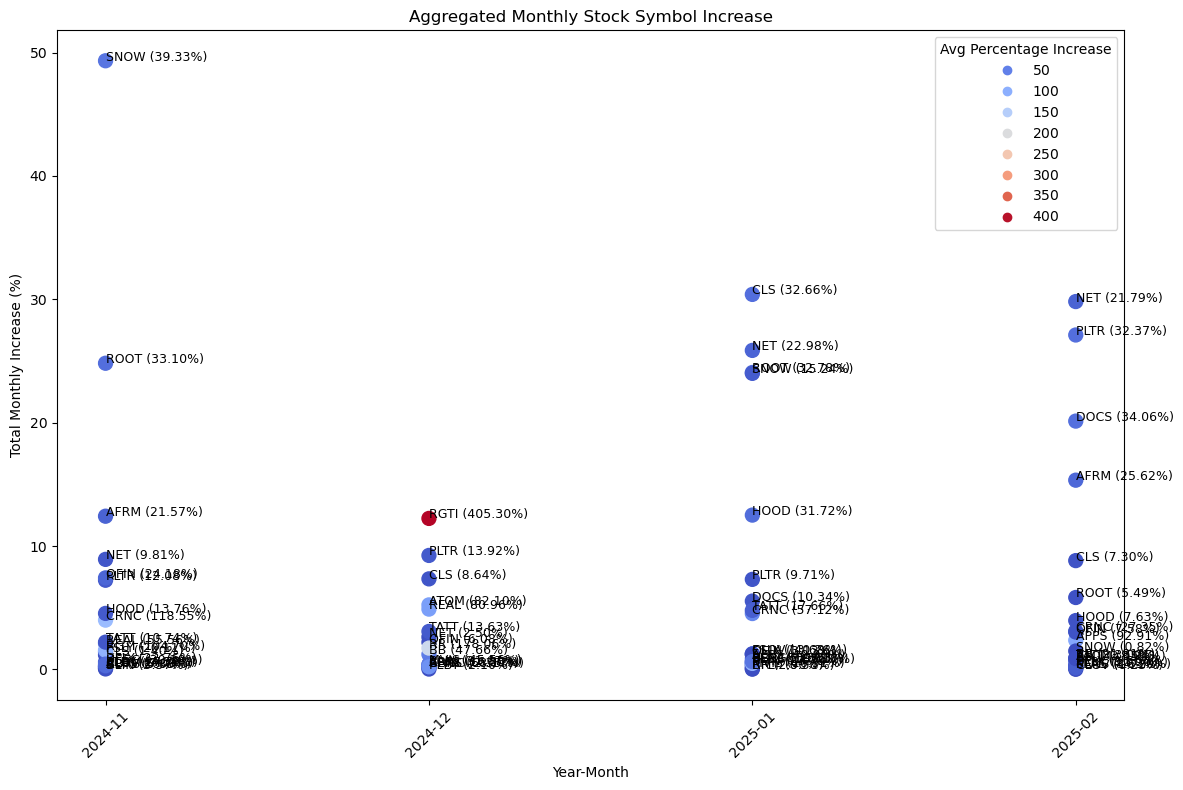

In [86]:
# Plotting
fig, ax = plt.subplots(figsize=(12, 8))

# Scatter plot
scatter = ax.scatter(
    agg_df['year_month_str'],
    agg_df['total_monthly_increase'],
    c=agg_df['avg_percentage_increase'],
    cmap='coolwarm',
    s=100
)

# Add labels
for i, row in agg_df.iterrows():
    ax.text(row['year_month_str'], row['total_monthly_increase'], f"{row['symbol']} ({row['avg_percentage_increase']:.2f}%)", fontsize=9)

# Formatting
ax.set_xticks(agg_df['year_month_str'].cat.categories)
ax.set_xticklabels(agg_df['year_month_str'].cat.categories, rotation=45)
ax.set_title('Aggregated Monthly Stock Symbol Increase')
ax.set_xlabel('Year-Month')
ax.set_ylabel('Total Monthly Increase (%)')
ax.legend(*scatter.legend_elements(), title='Avg Percentage Increase')

plt.tight_layout()
plt.show()

In [87]:
import numpy as np

#print(agg_df)
# Group the data by symbol and month, then calculate the mean percentage increase
grouped = agg_df.groupby(['symbol', 'year_month_str'],observed=False)['avg_percentage_increase'].mean().unstack()

# Fill NaN values with 0
grouped = grouped.fillna(0)

# Calculate the overall percentage increase for each symbol
overall_increase = grouped.sum(axis=1)

#print(grouped)
# Sort the DataFrame by the total percentage increase (sum across all months)
#sorted_df = grouped.sort_values(by=grouped.columns.tolist(), ascending=True)
sorted_df = grouped.loc[overall_increase.sort_values().index]
print(sorted_df)

year_month_str     2024-11     2024-12     2025-01    2025-02
symbol                                                       
BFLY             22.761190    0.000000    0.503778   9.595962
FSLY             20.113309    0.000000   13.680784   0.000000
QFIN             24.177256    6.080710    3.127431   7.584477
DOCS              0.000000    0.000000   10.343534  34.060923
TATT             10.743807   13.628318   17.662238   3.087716
AFRM             21.566248    0.000000    0.000000  25.617902
CLOV              7.076924    0.000000   40.255582   0.232024
CLS               1.403760    8.639364   32.663588   7.296492
HOOD             13.757579    0.000000   31.719073   7.630056
SNOW             39.327279    0.000000   15.237128   0.816262
NET               9.811899    2.503567   22.978490  21.791880
BLIN              3.571425   31.666665   23.749999   0.000000
PLTR             12.080206   13.917756    9.708731  32.374016
USEG             30.281696    0.000000   39.130434   0.000000
MVIS    

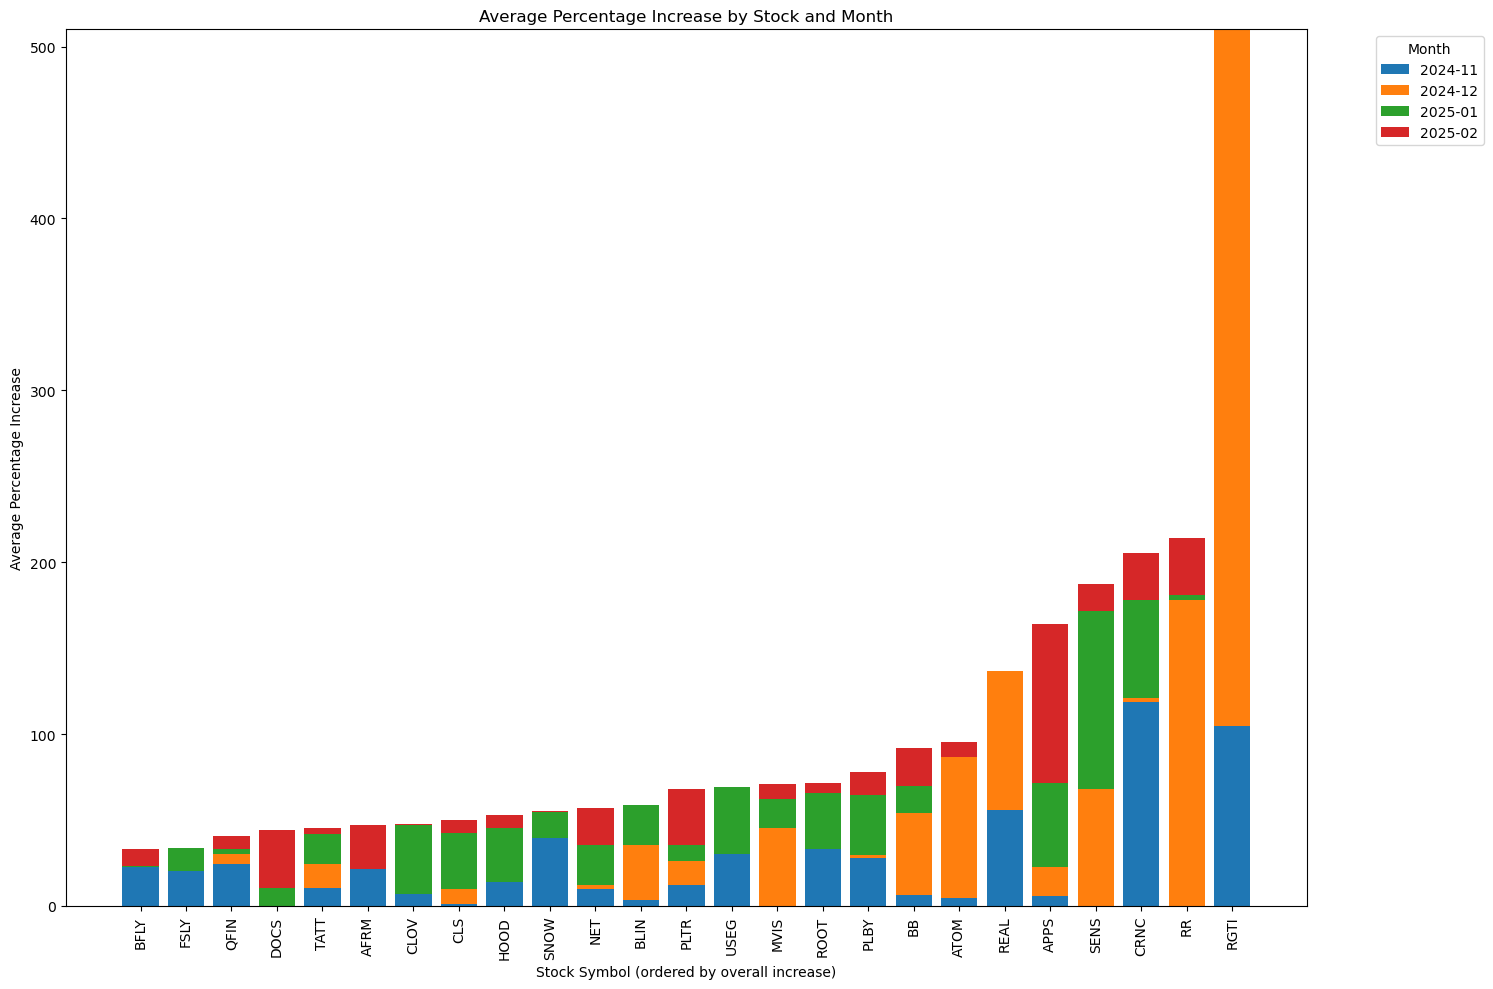

In [88]:
# Create the stacked bar chart
fig, ax = plt.subplots(figsize=(15, 10))

bottom = np.zeros(len(sorted_df))

for month in sorted_df.columns:
    ax.bar(sorted_df.index, sorted_df[month], bottom=bottom, label=month)
    bottom += sorted_df[month]

# Customize the chart
ax.set_title('Average Percentage Increase by Stock and Month')
ax.set_xlabel('Stock Symbol (ordered by overall increase)')
ax.set_ylabel('Average Percentage Increase')
ax.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Adjust layout to prevent cutting off labels
plt.tight_layout()

# Show the plot
plt.show()